In [ ]:
import os #manage files , paths , dir in the system
import torch #pytorch library
import pandas as pd # Pandas for structured data manipulation
from torch import nn #Cnn modules (layers, loss functions)
from torchvision import transforms #Image transformations for preprocessing and augmentation
from torch.utils.data import Dataset, DataLoader #Custom dataset class and data loading utilities
from transformers import ViTModel #Pretrained Vision Transformer (ViT) model from Hugging Face
from PIL import Image #For opening and handling images
from tqdm import tqdm #Progress bar for loops
import numpy as np #For numerical operations, array handling
from sklearn.metrics import mean_squared_error, r2_score #Regression evaluation metrics
import matplotlib.pyplot as plt #For plotting and visualizing results

In [ ]:
#mount colab
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#Custom Dataset using image paths from CSV
class OliveYieldDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        yield_value = self.df.iloc[idx]['yield_kg']

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(yield_value, dtype=torch.float32), img_path

In [ ]:
#Paths to CSVs (already linked to images)
train_csv = "/content/drive/MyDrive/TradionalOlives/oliveTreeRealdata/train_realdata.csv"
valid_csv = "/content/drive/MyDrive/TradionalOlives/oliveTreeRealdata/valid_realdata.csv"
test_csv  = "/content/drive/MyDrive/TradionalOlives/oliveTreeRealdata/test_realdata.csv"

In [ ]:
#Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
#Datasets and Dataloaders
batch_size = 16

train_dataset = OliveYieldDataset(train_csv, transform)
valid_dataset = OliveYieldDataset(valid_csv, transform)
test_dataset  = OliveYieldDataset(test_csv, transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, batch_size=batch_size)

In [ ]:
#ViT Model Modified for Regression
class ViTYieldRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        self.regressor = nn.Sequential(
            nn.Linear(self.vit.config.hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        outputs = self.vit(pixel_values=x)
        cls_token = outputs.last_hidden_state[:, 0, :]
        return self.regressor(cls_token).squeeze(1)

In [ ]:

#Train Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ViTYieldRegressor().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = nn.MSELoss()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
!pip install --upgrade scikit-learn


In [ ]:

# Define base path
base_path = "/content/drive/MyDrive/VitSegmentation"

# Define folders to create
folders = ['checkpoints', 'plots']
for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Folders created and ready!")

Folders created and ready!


In [ ]:
checkpoints_dir="/content/drive/MyDrive/VitSegmentation/checkpoints"
plots_dir="/content/drive/MyDrive/VitSegmentation/plots"

In [ ]:
#Training Loop
def train_model(epochs=10):
    train_losses = []
    best_val_loss = float("inf")

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels, _ in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        print(f"Epoch {epoch+1} Training Loss: {avg_train_loss:.4f}")

        val_preds, val_actuals, _ = evaluate_model(valid_loader)
        val_mse = mean_squared_error(val_actuals, val_preds)  # Removed squared=True
        val_rmse = np.sqrt(val_mse)
        print(f"Validation RMSE: {val_rmse:.4f}")

        if val_mse < best_val_loss:
            best_val_loss = val_mse
            torch.save(model.state_dict(), os.path.join(checkpoints_dir, "best_vit_model.pt"))
            print(" Best model saved.")

    # Plot training loss
    plt.plot(train_losses, label="Train Loss")
    plt.title("Training Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig(os.path.join(plots_dir, "training_loss.png"))
    plt.close()


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(loader, name="Set"):
    model.eval()
    preds, actuals, paths = [], [], []
    with torch.no_grad():
        for images, labels, img_paths in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds.extend(outputs.cpu().numpy())
            actuals.extend(labels.cpu().numpy())
            paths.extend(img_paths)

    # Compute metrics using correct variable names
    mse = mean_squared_error(actuals, preds)
    rmse = mse ** 0.5
    mae = mean_absolute_error(actuals, preds)
    r2 = r2_score(actuals, preds)

    print(f"\n Evaluation on {name}:")
    print(f"  - RMSE: {rmse:.2f}")
    print(f"  - MAE:  {mae:.2f}")
    print(f"  - R²:   {r2:.4f}")

    return preds, actuals, paths


In [ ]:
# Train the model
train_model(epochs=40)

100%|██████████| 80/80 [09:32<00:00,  7.15s/it]


Epoch 1 Training Loss: 6590.7629
Validation RMSE: 64.7867
✅ Best model saved.


100%|██████████| 80/80 [00:57<00:00,  1.40it/s]


Epoch 2 Training Loss: 6208.7770
Validation RMSE: 61.5741
✅ Best model saved.


100%|██████████| 80/80 [01:01<00:00,  1.29it/s]


...

Epoch 38 Training Loss: 142.3961
Validation RMSE: 13.6772


100%|██████████| 80/80 [00:55<00:00,  1.45it/s]


Epoch 39 Training Loss: 123.5326
Validation RMSE: 14.5880


100%|██████████| 80/80 [00:55<00:00,  1.45it/s]


Epoch 40 Training Loss: 116.1893
Validation RMSE: 12.5964


In [ ]:
#evaluation on training data
train_preds, train_actuals, train_paths = evaluate_model(train_loader, name="Training")


📊 Evaluation on Training:
  - RMSE: 18.15
  - MAE:  7.79
  - R²:   0.7799


In [ ]:
#evaluation on test data
test_preds, test_actuals, test_paths = evaluate_model(test_loader, name="Test")



📊 Evaluation on Test:
  - RMSE: 14.11
  - MAE:  12.56
  - R²:   0.2306


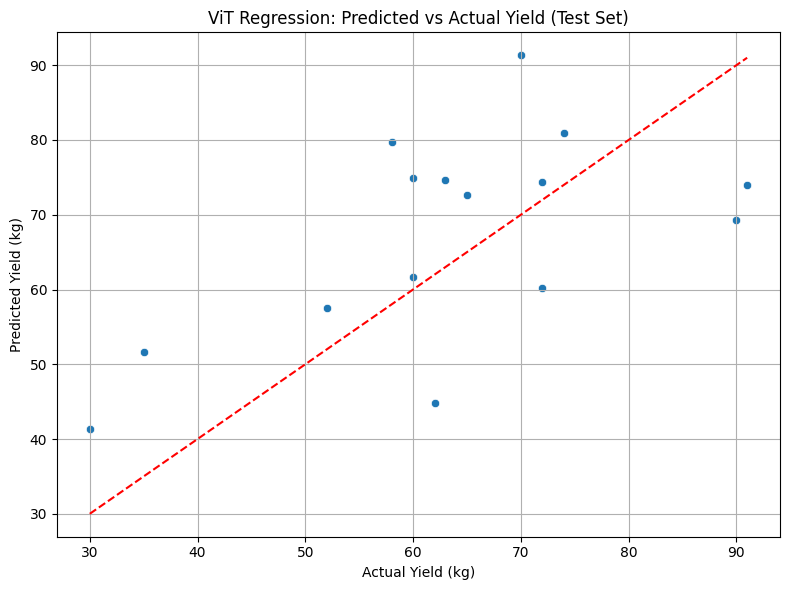

✅ Regression plot saved at: /content/drive/MyDrive/VitSegmentation/plots/vit_regression_plot_testset.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot regression for test set
plt.figure(figsize=(8, 6))
sns.scatterplot(x=test_actuals, y=test_preds)
plt.plot([min(test_actuals), max(test_actuals)], [min(test_actuals), max(test_actuals)], color='red', linestyle='--')
plt.xlabel("Actual Yield (kg)")
plt.ylabel("Predicted Yield (kg)")
plt.title("ViT Regression: Predicted vs Actual Yield (Test Set)")
plt.grid(True)
plt.tight_layout()

# Save plot
regression_plot_path = os.path.join(plots_dir, "vit_regression_plot_testset.png")
plt.savefig(regression_plot_path)
plt.show()

print(f" Regression plot saved at: {regression_plot_path}")


In [ ]:
# Create a DataFrame for CSV output
test_results_df = pd.DataFrame({
    "image_path": test_paths,
    "actual_yield": test_actuals,
    "predicted_yield": test_preds
})

# Save to CSV
csv_save_path = os.path.join(base_path, "vit_test_predictions.csv")
test_results_df.to_csv(csv_save_path, index=False)

print(f" Test predictions CSV saved to: {csv_save_path}")


 Test predictions CSV saved to: /content/drive/MyDrive/VitSegmentation/vit_test_predictions.csv


In [ ]:
import pandas as pd

# Load the CSV you saved
csv_path = os.path.join(base_path, "vit_test_predictions.csv")
df = pd.read_csv(csv_path)

# Display the first few rows
print("📋 First rows of the prediction results:")
display(df.head(20))  # shows nicely formatted table in Colab


📋 First rows of the prediction results:


,image_path,actual_yield,predicted_yield
0,/content/drive/MyDrive/TradionalOlives/oliveTr...,72.0,74.386720
1,/content/drive/MyDrive/TradionalOlives/oliveTr...,70.0,91.334050
2,/content/drive/MyDrive/TradionalOlives/oliveTr...,35.0,51.590714
3,/content/drive/MyDrive/TradionalOlives/oliveTr...,90.0,69.347950
4,/content/drive/MyDrive/TradionalOlives/oliveTr...,60.0,74.901855
5,/content/drive/MyDrive/TradionalOlives/oliveTr...,52.0,57.490726
6,/content/drive/MyDrive/TradionalOlives/oliveTr...,62.0,44.831066
7,/content/drive/MyDrive/TradionalOlives/oliveTr...,63.0,74.701454
8,/content/drive/MyDrive/TradionalOlives/oliveTr...,65.0,72.577640
9,/content/drive/MyDrive/TradionalOlives/oliveTr...,30.0,41.361362
